## Introducción

...

## Objetivo del analisis

...

## Preguntas

...

## Repositorio

Link: https://github.com/mnahuelanca/segmentacion-clientes

## Librerias y config.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import plotly.express 
print("Librerias importadas correctamente")

Librerias importadas correctamente


In [32]:

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Importar datos

Link: https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation

In [33]:
df = pd.read_csv("./datos/train.csv")
print("Datos cargados correctamente")

Datos cargados correctamente


## EDA y ETL

info, describe, unicos, nulos, duplicados, categoricos, numericos,
eliminar, exportar csv final

In [34]:
df.head(5)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


* ID = Identificador
* Gender = Genero del cliente 
* Ever_Married = Estado civil del cliente
* Age = Edad del cliente 
* Graduated = ¿El cliente es graduado?
* Prefession = Profesión del cliente 
* Work_Experience = Experiencia laboral en años
* Spending_Score = Puntuación de gasto
* Family_Size = Tamaño familiar (integrantes)
* Var_1 = Categoría anonimizada para el cliente
* Segmentation = Segmento del cliente

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


* 8068 filas,
* 11 columnas,
* 3 tipos de datos. Float, Int y Object,
* Hay valores nulos o faltantes
* Hay 1 variables anonimizada (var_1)

In [36]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [37]:
duplicados = df.duplicated().sum()
print(f"Total de filas duplicadas: {duplicados}")

Total de filas duplicadas: 0


In [38]:
nulos = df.isnull().sum()
print(f"Total de filas nulas: \n{nulos}")

Total de filas nulas: 
ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64


In [39]:
# Identificar tipos de valores en cada categoría que tenga valores nulos
columns_with_nulls = ['Ever_Married', 'Graduated', 'Profession', 'Work_Experience', 'Family_Size', 'Var_1']
for col in columns_with_nulls:
    print(f"Valores únicos en {col}: {df[col].unique()}")

Valores únicos en Ever_Married: ['No' 'Yes' nan]
Valores únicos en Graduated: ['No' 'Yes' nan]
Valores únicos en Profession: ['Healthcare' 'Engineer' 'Lawyer' 'Entertainment' 'Artist' 'Executive'
 'Doctor' 'Homemaker' 'Marketing' nan]
Valores únicos en Work_Experience: [ 1. nan  0.  4.  9. 12.  3. 13.  5.  8. 14.  7.  2.  6. 10. 11.]
Valores únicos en Family_Size: [ 4.  3.  1.  2.  6. nan  5.  8.  7.  9.]
Valores únicos en Var_1: ['Cat_4' 'Cat_6' 'Cat_7' 'Cat_3' 'Cat_1' 'Cat_2' nan 'Cat_5']


In [40]:
# Analizar y tratar valores nulos
# Para columnas categóricas (object), rellenar con la moda o 'Unknown'
# Para columnas numéricas (float/int), rellenar con la mediana (no con 0, ya que podría sesgar datos)

for col in columns_with_nulls:
    if df[col].dtype == 'object':
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        df[col].fillna(mode_val, inplace=True)
        print(f"Columna {col} (categórica): rellenada con moda '{mode_val}'")
    else:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Columna {col} (numérica): rellenada con mediana {median_val}")

# Verificar que no queden nulos
print("Nulos después del tratamiento:")
print(df.isnull().sum())

Columna Ever_Married (categórica): rellenada con moda 'Yes'
Columna Graduated (categórica): rellenada con moda 'Yes'
Columna Profession (categórica): rellenada con moda 'Artist'
Columna Work_Experience (numérica): rellenada con mediana 1.0
Columna Family_Size (numérica): rellenada con mediana 3.0
Columna Var_1 (categórica): rellenada con moda 'Cat_6'
Nulos después del tratamiento:
ID                 0
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
dtype: int64


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16788\3571999179.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_16788\3571999179.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [41]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,8068.000000,8068.000000
mean,463479.214551,43.466906,2.472980,2.856346
std,2595.381232,16.711696,3.265248,1.499577
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [42]:
# Identificar valores únicos en cada columna
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"Valores únicos en {col}: {unique_vals}")

Valores únicos en ID: [462809 462643 466315 ... 465406 467299 461879]
Valores únicos en Gender: ['Male' 'Female']
Valores únicos en Ever_Married: ['No' 'Yes']
Valores únicos en Age: [22 38 67 40 56 32 33 61 55 26 19 70 58 41 31 79 49 18 36 35 45 42 83 27
 28 47 29 57 76 25 72 48 74 59 39 51 30 63 52 60 68 86 50 43 80 37 46 69
 78 71 82 23 20 85 21 53 62 75 65 89 66 73 77 87 84 81 88]
Valores únicos en Graduated: ['No' 'Yes']
Valores únicos en Profession: ['Healthcare' 'Engineer' 'Lawyer' 'Entertainment' 'Artist' 'Executive'
 'Doctor' 'Homemaker' 'Marketing']
Valores únicos en Work_Experience: [ 1.  0.  4.  9. 12.  3. 13.  5.  8. 14.  7.  2.  6. 10. 11.]
Valores únicos en Spending_Score: ['Low' 'Average' 'High']
Valores únicos en Family_Size: [4. 3. 1. 2. 6. 5. 8. 7. 9.]
Valores únicos en Var_1: ['Cat_4' 'Cat_6' 'Cat_7' 'Cat_3' 'Cat_1' 'Cat_2' 'Cat_5']
Valores únicos en Segmentation: ['D' 'A' 'B' 'C']


In [43]:
for col in df.columns:
    if col == 'ID':
        continue
    print(f"\nConteo de valores únicos en {col}:")
    if col in ['Age', 'Work_Experience', 'Family_Size']:
        if col == 'Age':
            bins = [1, 25, 35, 45, 55, 65, 100]
        elif col == 'Work_Experience':
            bins = [0, 2, 5, 10, 15]
        elif col == 'Family_Size':
            bins = [1, 2, 4, 6, 10]
        counts = df[col].value_counts(bins=bins, sort=False)
        print(counts)
    else:
        counts = df[col].value_counts()
        print(counts)


Conteo de valores únicos en Gender:
Gender
Male      4417
Female    3651
Name: count, dtype: int64

Conteo de valores únicos en Ever_Married:
Ever_Married
Yes    4783
No     3285
Name: count, dtype: int64

Conteo de valores únicos en Age:
(0.999, 25.0]     998
(25.0, 35.0]     1945
(35.0, 45.0]     1923
(45.0, 55.0]     1390
(55.0, 65.0]      805
(65.0, 100.0]    1007
Name: count, dtype: int64

Conteo de valores únicos en Graduated:
Graduated
Yes    5046
No     3022
Name: count, dtype: int64

Conteo de valores únicos en Profession:
Profession
Artist           2640
Healthcare       1332
Entertainment     949
Engineer          699
Doctor            688
Lawyer            623
Executive         599
Marketing         292
Homemaker         246
Name: count, dtype: int64

Conteo de valores únicos en Work_Experience:
(-0.001, 2.0]    5787
(2.0, 5.0]        702
(5.0, 10.0]      1390
(10.0, 15.0]      189
Name: count, dtype: int64

Conteo de valores únicos en Spending_Score:
Spending_Score
Low   

In [44]:
df.rename(columns={
    'ID': 'Identificador',
    'Gender': 'Genero',
    'Ever_Married': 'Estado_Civil',
    'Age': 'Edad',
    'Graduated': 'Graduado',
    'Profession': 'Profesion',
    'Work_Experience': 'Experiencia_Laboral',
    'Spending_Score': 'Puntuacion_Gasto',
    'Family_Size': 'Tamano_Familiar',
    'Var_1': 'Categoria_Anonimizada',
    'Segmentation': 'Segmento'
}, inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Identificador          8068 non-null   int64  
 1   Genero                 8068 non-null   object 
 2   Estado_Civil           8068 non-null   object 
 3   Edad                   8068 non-null   int64  
 4   Graduado               8068 non-null   object 
 5   Profesion              8068 non-null   object 
 6   Experiencia_Laboral    8068 non-null   float64
 7   Puntuacion_Gasto       8068 non-null   object 
 8   Tamano_Familiar        8068 non-null   float64
 9   Categoria_Anonimizada  8068 non-null   object 
 10  Segmento               8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [45]:
df.drop('Categoria_Anonimizada', axis=1, inplace=True)
print("Columna 'Categoria_Anonimizada' eliminada del DataFrame.")

Columna 'Categoria_Anonimizada' eliminada del DataFrame.


In [46]:
df.head()

,Identificador,Genero,Estado_Civil,Edad,Graduado,Profesion,Experiencia_Laboral,Puntuacion_Gasto,Tamano_Familiar,Segmento
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,D
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,B
4,462669,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,A


In [47]:
# Generate dummy variables for Puntuacion_Gasto
dummies_gasto = pd.get_dummies(df['Puntuacion_Gasto'], prefix='Gasto')

# Add the dummy variables to the dataframe
df = pd.concat([df, dummies_gasto], axis=1)

# Display the first few rows to verify
df.head()

,Identificador,Genero,Estado_Civil,Edad,Graduado,Profesion,Experiencia_Laboral,Puntuacion_Gasto,Tamano_Familiar,Segmento,Gasto_Average,Gasto_High,Gasto_Low
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,D,False,False,True
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,A,True,False,False
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,B,False,False,True
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,B,False,True,False
4,462669,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,A,False,True,False


In [48]:
df.describe(include='object')

,Genero,Estado_Civil,Graduado,Profesion,Puntuacion_Gasto,Segmento
count,8068,8068,8068,8068,8068,8068
unique,2,2,2,9,3,4
top,Male,Yes,Yes,Artist,Low,D
freq,4417,4783,5046,2640,4878,2268


## Exportar DF

In [49]:
df.to_csv('dfSegmentado.csv', index=False)
print("DataFrame guardado como 'dfSegmentado.csv'")

DataFrame guardado como 'dfSegmentado.csv'


In [50]:
dfFinal = pd.read_csv('dfSegmentado.csv')
dfFinal.head()

,Identificador,Genero,Estado_Civil,Edad,Graduado,Profesion,Experiencia_Laboral,Puntuacion_Gasto,Tamano_Familiar,Segmento,Gasto_Average,Gasto_High,Gasto_Low
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,D,False,False,True
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,A,True,False,False
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,B,False,False,True
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,B,False,True,False
4,462669,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,A,False,True,False


## Graficos

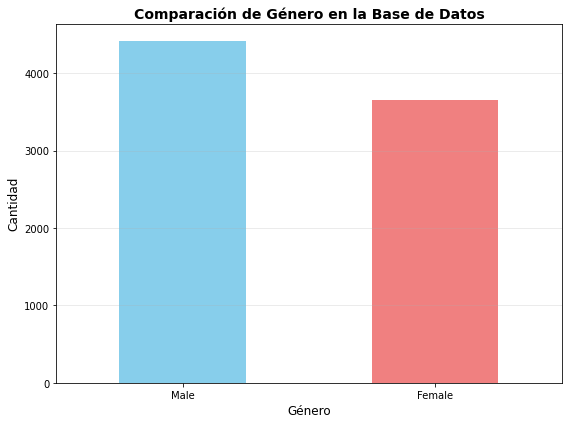

In [51]:
# Create a bar chart comparing the count of males and females
gender_counts = dfFinal['Genero'].value_counts()
plt.figure(figsize=(8, 6))
gender_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Comparación de Género en la Base de Datos', fontsize=14, fontweight='bold')
plt.xlabel('Género', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

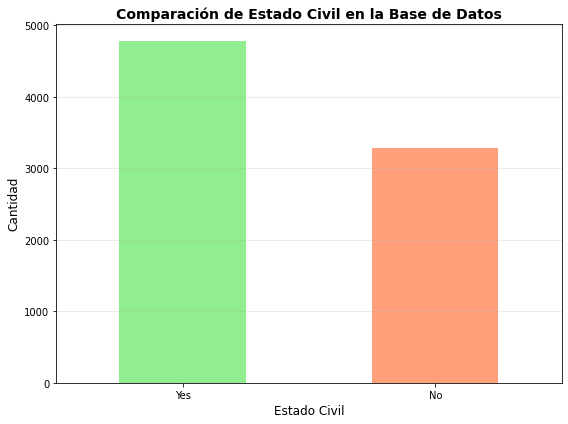

In [52]:
# Create a bar chart comparing married vs unmarried customers
marital_counts = dfFinal['Estado_Civil'].value_counts()
plt.figure(figsize=(8, 6))
marital_counts.plot(kind='bar', color=['lightgreen', 'lightsalmon'])
plt.title('Comparación de Estado Civil en la Base de Datos', fontsize=14, fontweight='bold')
plt.xlabel('Estado Civil', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

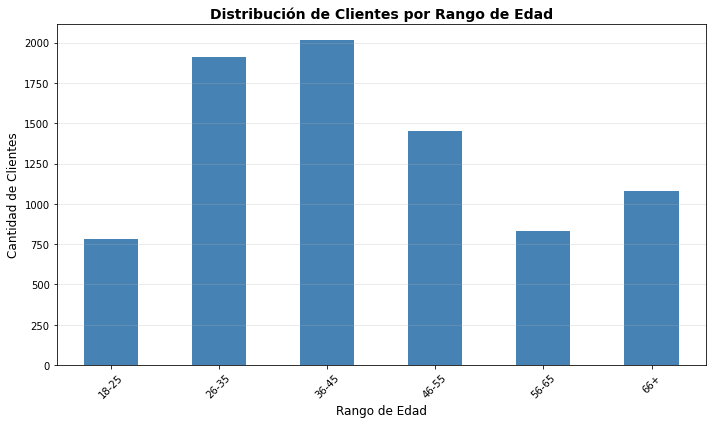

In [53]:
# Create age ranges for better visualization
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
dfFinal['Rango_Edad'] = pd.cut(dfFinal['Edad'], bins=age_bins, labels=age_labels, right=False)

# Count customers by age range
age_range_counts = dfFinal['Rango_Edad'].value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(10, 6))
age_range_counts.plot(kind='bar', color='steelblue')
plt.title('Distribución de Clientes por Rango de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Rango de Edad', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

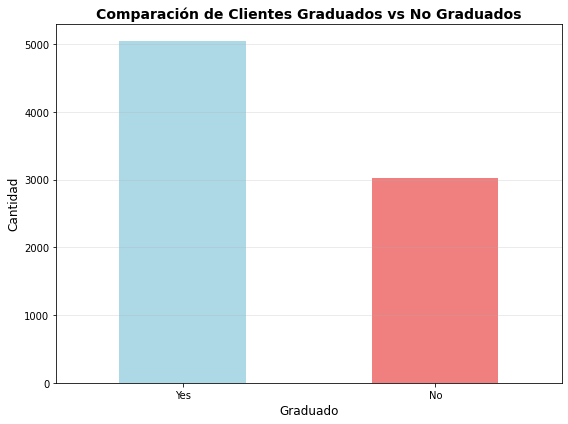

In [54]:
# Create a bar chart comparing graduated vs non-graduated customers
graduated_counts = dfFinal['Graduado'].value_counts()
plt.figure(figsize=(8, 6))
graduated_counts.plot(kind='bar', color=['lightblue', 'lightcoral'])
plt.title('Comparación de Clientes Graduados vs No Graduados', fontsize=14, fontweight='bold')
plt.xlabel('Graduado', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

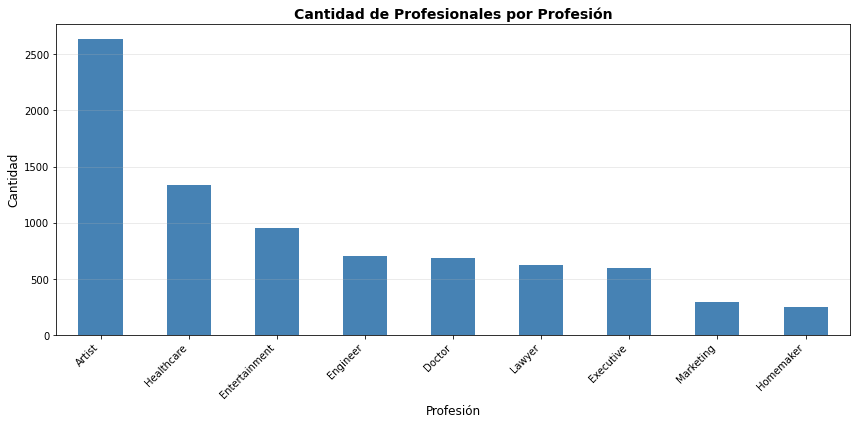

In [55]:
# Create a bar chart showing the count of professionals by profession
profession_counts = dfFinal['Profesion'].value_counts()
plt.figure(figsize=(12, 6))
profession_counts.plot(kind='bar', color='steelblue')
plt.title('Cantidad de Profesionales por Profesión', fontsize=14, fontweight='bold')
plt.xlabel('Profesión', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

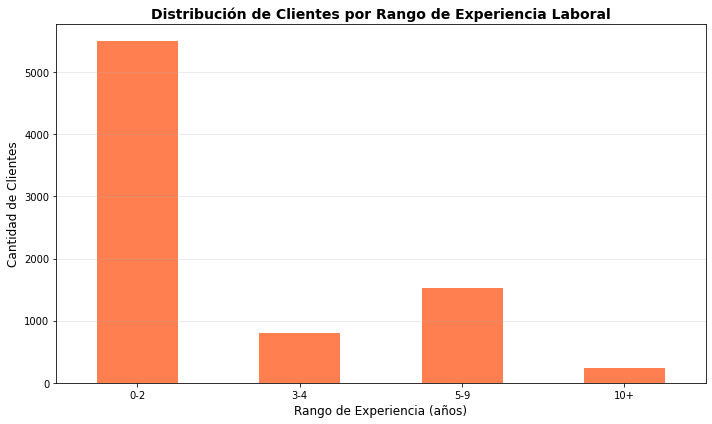

In [56]:
# Create work experience ranges for visualization
experience_bins = [0, 2, 5, 10, 15]
experience_labels = ['0-2', '3-4', '5-9', '10+']
dfFinal['Rango_Experiencia'] = pd.cut(dfFinal['Experiencia_Laboral'], bins=experience_bins, labels=experience_labels, right=False)

# Count customers by experience range
experience_range_counts = dfFinal['Rango_Experiencia'].value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(10, 6))
experience_range_counts.plot(kind='bar', color='coral')
plt.title('Distribución de Clientes por Rango de Experiencia Laboral', fontsize=14, fontweight='bold')
plt.xlabel('Rango de Experiencia (años)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

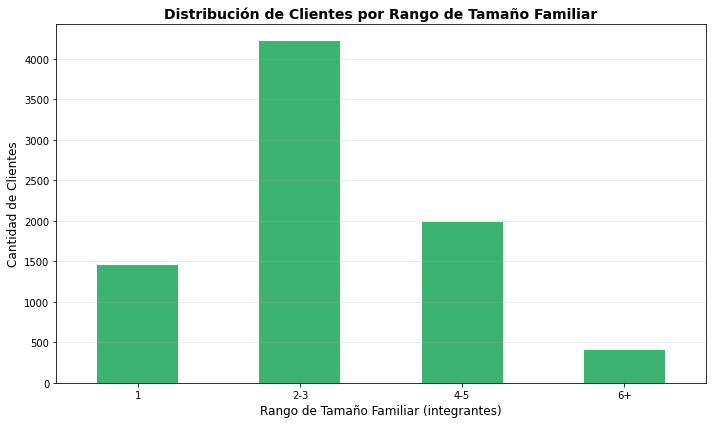

In [57]:
# Create family size ranges for visualization
family_bins = [1, 2, 4, 6, 10]
family_labels = ['1', '2-3', '4-5', '6+']
dfFinal['Rango_Tamano_Familiar'] = pd.cut(dfFinal['Tamano_Familiar'], bins=family_bins, labels=family_labels, right=False)

# Count customers by family size range
family_range_counts = dfFinal['Rango_Tamano_Familiar'].value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(10, 6))
family_range_counts.plot(kind='bar', color='mediumseagreen')
plt.title('Distribución de Clientes por Rango de Tamaño Familiar', fontsize=14, fontweight='bold')
plt.xlabel('Rango de Tamaño Familiar (integrantes)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones 

...